In [1]:
#Uber Ride Data Analysis Project
#Author: Reda El Motassadiq
#Goal: analyzing Uber booking data to uncover insights about revenue, demand patterns, and operational efficiency using Python (Pandas & Matplotlib).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#print(plt.style.available)

In [4]:
#Cleaning Data


df=pd.read_csv("ncr_ride_bookings.csv")
pd.set_option('display.max_columns', 21)

df['DateTime']= pd.to_datetime(df['Date']+' '+df['Time'])
df.drop(columns =['Date', 'Time'], inplace=True)

df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna("Not Added")
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna("Not Added")
df = df.fillna('Not added')

cols_to_clean = ['Booking ID', 'Customer ID', 'Vehicle Type']
for col in cols_to_clean:
    df[col] = df[col].str.replace('"', '').str.strip()

In [5]:
df

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,Not added,Not added,Not added,Not Added,Not added,Not Added,Not added,Not added,Not added,Not added,Not added,Not added,Not added,2024-03-23 12:29:38
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,Not added,Not Added,Not added,Not Added,1.0,Vehicle Breakdown,237.0,5.73,Not added,Not added,UPI,2024-11-29 18:01:39
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,Not added,Not Added,Not added,Not Added,Not added,Not added,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,Not added,Not Added,Not added,Not Added,Not added,Not added,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,Not added,Not Added,Not added,Not Added,Not added,Not added,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,Not added,Not Added,Not added,Not Added,Not added,Not added,475.0,40.08,3.7,4.1,Uber Wallet,2024-11-11 19:34:01
149996,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,Not added,Not Added,Not added,Not Added,Not added,Not added,1093.0,21.31,4.8,5.0,UPI,2024-11-24 15:55:09
149997,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,Not added,Not Added,Not added,Not Added,Not added,Not added,852.0,15.93,3.9,4.4,Cash,2024-09-18 10:55:15
149998,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,Not added,Not Added,Not added,Not Added,Not added,Not added,333.0,45.54,4.1,3.7,UPI,2024-10-05 07:53:34


In [6]:
#Revenue Analysis by Vehicle Type
#Objective: Identify which vehicle category generates the highest revenue for the company.

df['Booking Value'] = pd.to_numeric(df['Booking Value'], errors='coerce')
care_value = df.groupby('Vehicle Type')['Booking Value'].sum()
care_value.sort_values(ascending=False)


Vehicle Type
Auto             12878422.0
Go Mini          10338496.0
Go Sedan          9369719.0
Bike              7837697.0
Premier Sedan     6275332.0
eBike             3618485.0
Uber XL           1528032.0
Name: Booking Value, dtype: float64

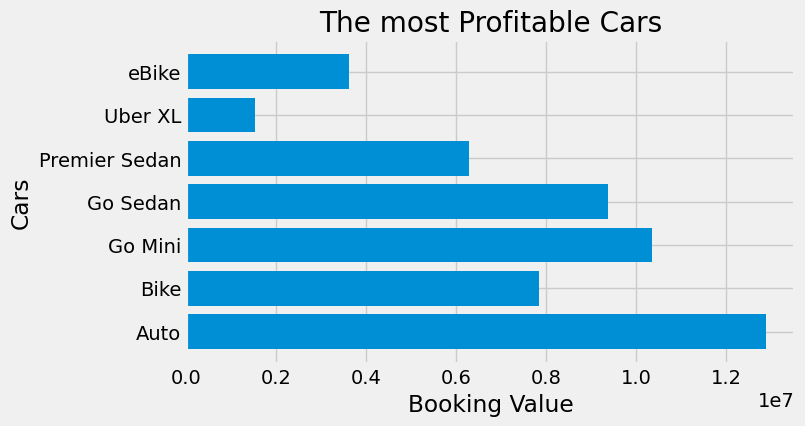

In [17]:
#visualisation of Revenue Analysis by Vehicle Type

plt.figure(figsize=(7,4))
plt.barh(care_value.index , care_value.values)
plt.title('The most Profitable Cars')
plt.xlabel('Booking Value')
plt.ylabel('Cars')
plt.grid(True)
plt.style.use('fivethirtyeight')

In [8]:
#Peak Hour Analysis (Rush Hours)
#Objective: Determine the time of day with the highest ride demand to optimize driver availability.

df['Hour'] = df['DateTime'].dt.hour
hourly_counts = df['Hour'].value_counts().sort_index()

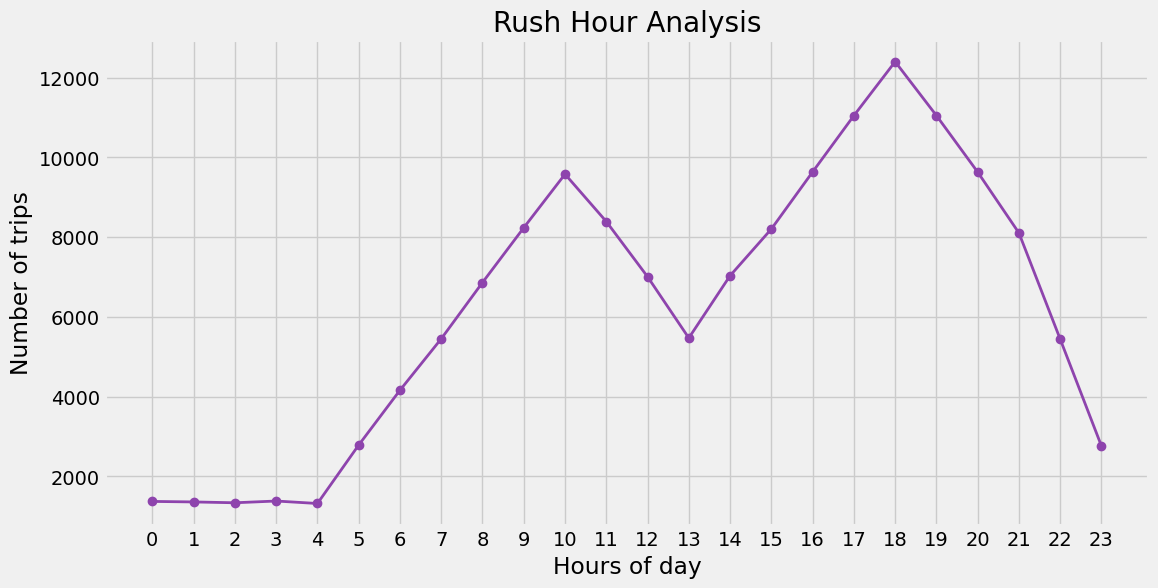

In [9]:
#Visualisation Peak Hour Analysis (Rush Hours)
plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='line', marker='o', color='#8E44AD', linewidth=2)
plt.title('Rush Hour Analysis')
plt.xlabel('Hours of day')
plt.ylabel('Number of trips')
plt.grid(True)
plt.xticks(range(0, 24)) 
plt.style.use('fivethirtyeight')

In [10]:
df['Booking Status'].value_counts(normalize =True)

Booking Status
Completed                0.62
Cancelled by Driver      0.18
No Driver Found          0.07
Cancelled by Customer    0.07
Incomplete               0.06
Name: proportion, dtype: float64

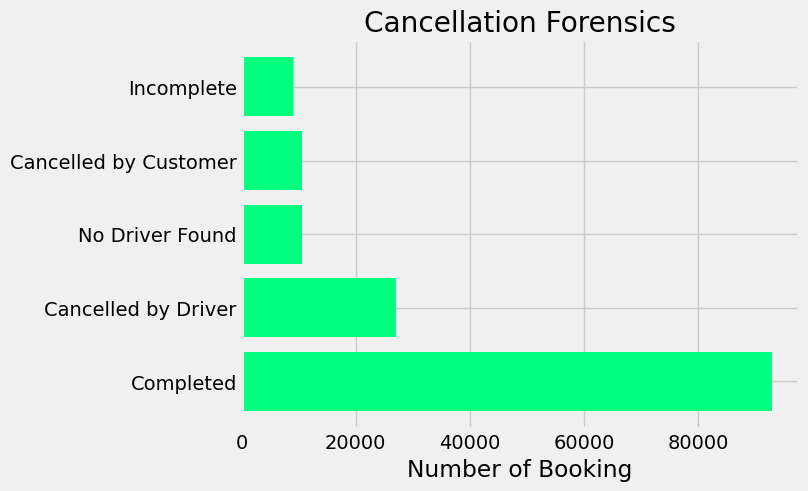

In [11]:
Booking_Satatus = df['Booking Status'].value_counts()


plt.barh(Booking_Satatus.index , Booking_Satatus.values, color ='springgreen')
plt.title('Cancellation Forensics')
plt.xlabel('Number of Booking')
plt.grid(True)
plt.style.use('fivethirtyeight')

In [12]:
#Driver Cancellation Forensics
#Objective: Investigate the primary reasons why drivers cancel trips.

df['Driver Cancellation Reason'].value_counts()

Driver Cancellation Reason
Not Added                              123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

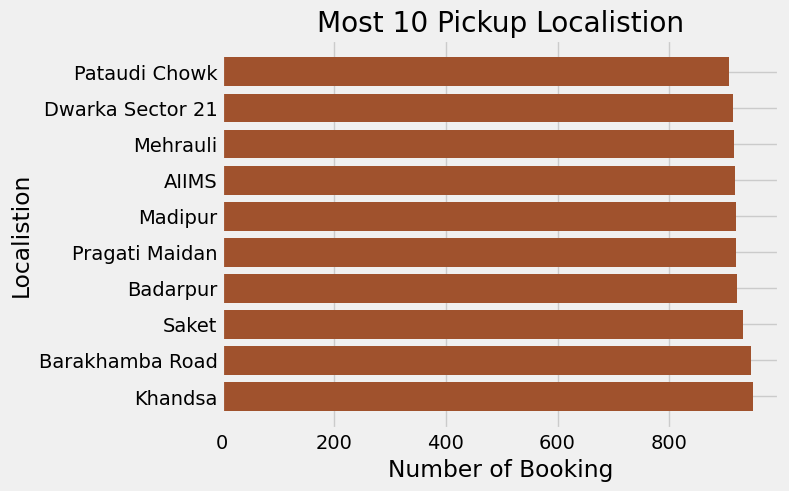

In [13]:
#Geospatial Analysis: Top Pickup Locations
#Objective: Identify the top 10 hotspots where customers request rides the most.

Pickup_localisation = df['Pickup Location'].value_counts().head(10)

plt.barh(Pickup_localisation.index , Pickup_localisation.values, color ='sienna')
plt.title('Most 10 Pickup Localistion')
plt.xlabel('Number of Booking')
plt.ylabel('Localistion')
plt.grid(True)
plt.style.use('fivethirtyeight')

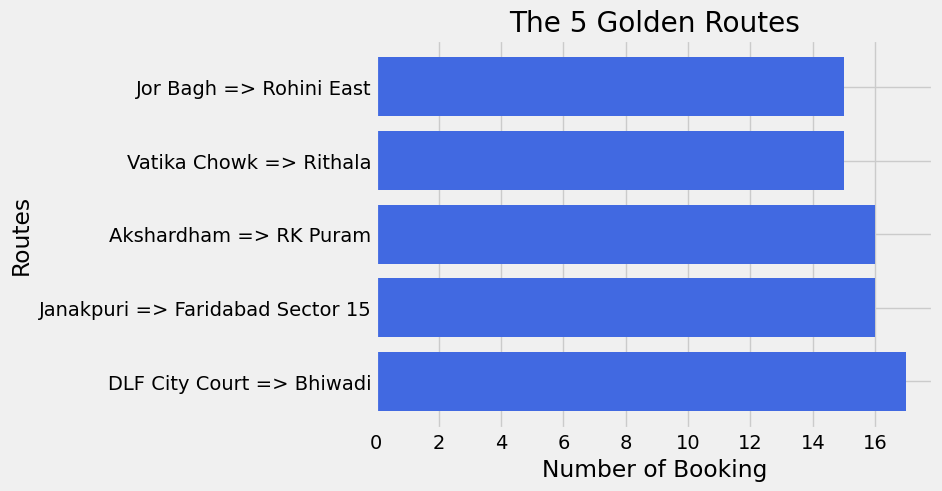

In [14]:
#Route Analysis: The Golden Routes
#Objective: Discover the most popular travel routes (Origin → Destination).

df['Route'] =df['Pickup Location'] + ' => ' +df['Drop Location']
Route = df['Route'].value_counts().head()

plt.barh(Route.index , Route.values, color ='royalblue')
plt.title('The 5 Golden Routes')
plt.xlabel('Number of Booking')
plt.ylabel('Routes')
plt.grid(True)
plt.style.use('fivethirtyeight')

In [15]:
#Pricing Efficiency: Average Price Per KM
#Objective: Compare the cost efficiency of different vehicle types.

df['Price_Per_KM']=df['Booking Value']/df['Ride Distance']
df.groupby('Vehicle Type')['Price_Per_KM'].mean()

Vehicle Type
Auto             38.085136
Bike             38.168779
Go Mini          37.642931
Go Sedan          38.22088
Premier Sedan    37.855816
Uber XL          37.932004
eBike            36.314851
Name: Price_Per_KM, dtype: object

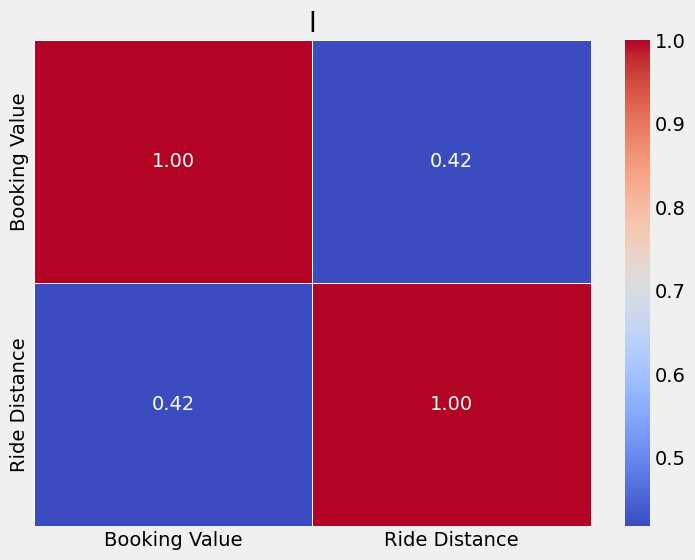

In [16]:
#Correlation Heatmap: Price vs. Distance
#Objective: Visualize the strength of the relationship between trip distance and trip cost.

df['Booking Value'] = pd.to_numeric(df['Booking Value'], errors='coerce').fillna(0)
df['Ride Distance'] = pd.to_numeric(df['Ride Distance'], errors='coerce').fillna(0)

numeric_df = df[['Booking Value', 'Ride Distance']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('ا')
plt.show()